## 1. Goal and Objective
### Goal
To build robust Linear Regression models that accurately predict bike rental counts on both a daily and hourly basis, leveraging environmental and seasonal factors, and to understand the key drivers of rental demand.  
### Objective
-- Data Loading & Initial Exploration: Load both daily (day.csv) and hourly (hour.csv) datasets, inspect their structure, and identify initial data characteristics.  
-- Data Preparation: Preprocess both datasets by converting date columns, correctly handling categorical features through one-hot encoding, and dropping irrelevant or redundant columns.  
-- Exploratory Data Analysis (EDA) & Visualization: Analyze distributions of the target variable and features. Visualize relationships between categorical/numerical features and rental counts using histograms, box plots, and correlation heatmaps.  
-- Model Training & Evaluation: Train separate Linear Regression models for daily and hourly predictions. Evaluate model performance using Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R²).  
-- Statistical Interpretation (OLS): Use statsmodels to obtain detailed OLS summaries, including p-values for feature significance and further diagnostic information.  
-- Visualization of Results: Plot actual vs. predicted values and residual distributions to assess model fit and assumptions.  

## 2. Importing Libraries and Loading Data

### Importing Required Libraries

Essential Python libraries for data manipulation, visualization, and machine learning are imported.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm # For OLS summary

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import os
from urllib.request import urlretrieve
import zipfile
import warnings

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

### Dataset Overview
The `bike.zip` file containing day.csv and hour.csv datasets is downloaded (if not present) and then loaded into pandas DataFrames.

In [2]:
zip_url = "https://samatrix-data.s3.ap-south-1.amazonaws.com/ML/Data-Bike-Share.zip"
local_zip = "bike.zip"

if not os.path.exists(local_zip):
    print("Downloading dataset zip file...")
    urlretrieve(zip_url, local_zip)
    print("Download complete.")
else:
    print("Dataset zip file already exists.")

with zipfile.ZipFile(local_zip) as z:
    with z.open("day.csv") as f:
        day_df = pd.read_csv(f)
    with z.open("hour.csv") as f:
        hour_df = pd.read_csv(f)

print("First 5 rows of Daily Data:")
print(day_df.head())
print("\nFirst 5 rows of Hourly Data:")
print(hour_df.head())

Dataset zip file already exists.
First 5 rows of Daily Data:
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   8

## 3. Initial Data Exploration
### Dataset Dimensions
This section checks the number of rows and columns for both daily and hourly datasets.

In [3]:
print(f"Daily data shape: {day_df.shape}")
print(f"Hourly data shape: {hour_df.shape}")

Daily data shape: (731, 16)
Hourly data shape: (17379, 17)


### Checking for Null Values
This code checks for any missing values in each column of both DataFrames.

In [4]:
print("\nNull values in Daily Data:")
print(day_df.isnull().sum())
print("\nNull values in Hourly Data:")
print(hour_df.isnull().sum())


Null values in Daily Data:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Null values in Hourly Data:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


### Descriptive Statistics
Descriptive statistics for numerical columns are generated to understand their distribution, central tendency, and spread for both datasets.

In [5]:
print("\nDescriptive statistics for Daily Data:")
print(day_df.describe().T)
print("\nDescriptive statistics for Hourly Data:")
print(hour_df.describe().T)


Descriptive statistics for Daily Data:
            count         mean          std        min          25%  \
instant     731.0   366.000000   211.165812   1.000000   183.500000   
season      731.0     2.496580     1.110807   1.000000     2.000000   
yr          731.0     0.500684     0.500342   0.000000     0.000000   
mnth        731.0     6.519836     3.451913   1.000000     4.000000   
holiday     731.0     0.028728     0.167155   0.000000     0.000000   
weekday     731.0     2.997264     2.004787   0.000000     1.000000   
workingday  731.0     0.683995     0.465233   0.000000     0.000000   
weathersit  731.0     1.395349     0.544894   1.000000     1.000000   
temp        731.0     0.495385     0.183051   0.059130     0.337083   
atemp       731.0     0.474354     0.162961   0.079070     0.337842   
hum         731.0     0.627894     0.142429   0.000000     0.520000   
windspeed   731.0     0.190486     0.077498   0.022392     0.134950   
casual      731.0   848.176471   686.

### **Outcome**:
Both day.csv and hour.csv are loaded successfully and show no missing values.
The day dataset has 731 records (days), and hour has 17379 records (hours).
Numerical features like temp, atemp, hum, windspeed are normalized. cnt, casual, registered are actual counts.

# DAILY DATA ANALYSIS (day.csv)
## 4. Daily Data Preparation
### Feature Labels for Visualization  
A dictionary is prepared to map numerical codes of categorical features to more readable labels, which will be used in visualizations.

In [ ]:
day_cat_cols_raw = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_cols_day = ['temp', 'atemp', 'hum', 'windspeed']

d_featurelabels = {
    'season': {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'},
    'yr': {0: '2011', 1: '2012'},
    'holiday': {0: 'No Holiday', 1: 'Holiday'},
    'workingday': {0: 'Weekend/Holiday', 1: 'Working Day'},
    'weathersit': {1: 'Clear', 2: 'Mist', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Snow/Fog'},
    'mnth': {1:'Jan', 2:'Feb', 3:'March', 4:'April', 5:'May', 6:'June', 7:'July', 8:'Aug', 9:'Sept', 10:'Oct', 11:'Nov', 12: 'Dec'},
    'weekday': {0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat'}
}

#### Data Cleaning and Feature Engineering
This section processes the day_df: converts dteday to datetime, one-hot encodes categorical variables, and drops irrelevant columns (instant, dteday, casual, registered).

In [ ]:
df_day_final = day_df.copy()
df_day_final['dteday'] = pd.to_datetime(df_day_final['dteday'])

# One-hot encode categorical features
df_day_final = pd.get_dummies(df_day_final, columns=day_cat_cols_raw, drop_first=True)

# Drop redundant columns
df_day_final = df_day_final.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)

print("Processed Daily Data (first 5 rows):")
print(df_day_final.head())

Processed Daily Data (first 5 rows):
       temp     atemp       hum  windspeed   cnt  season_2  season_3  \
0  0.344167  0.363625  0.805833   0.160446   985     False     False   
1  0.363478  0.353739  0.696087   0.248539   801     False     False   
2  0.196364  0.189405  0.437273   0.248309  1349     False     False   
3  0.200000  0.212122  0.590435   0.160296  1562     False     False   
4  0.226957  0.229270  0.436957   0.186900  1600     False     False   

   season_4   yr_1  mnth_2  ...  holiday_1  weekday_1  weekday_2  weekday_3  \
0     False  False   False  ...      False      False      False      False   
1     False  False   False  ...      False      False      False      False   
2     False  False   False  ...      False       True      False      False   
3     False  False   False  ...      False      False       True      False   
4     False  False   False  ...      False      False      False       True   

   weekday_4  weekday_5  weekday_6  workingday_1  weath

## 5. Daily EDA and Visualizations
#### Distribution of Total Daily Bike Rentals
A histogram with a Kernel Density Estimate (KDE) plot is used to visualize the distribution of the target variable (cnt).

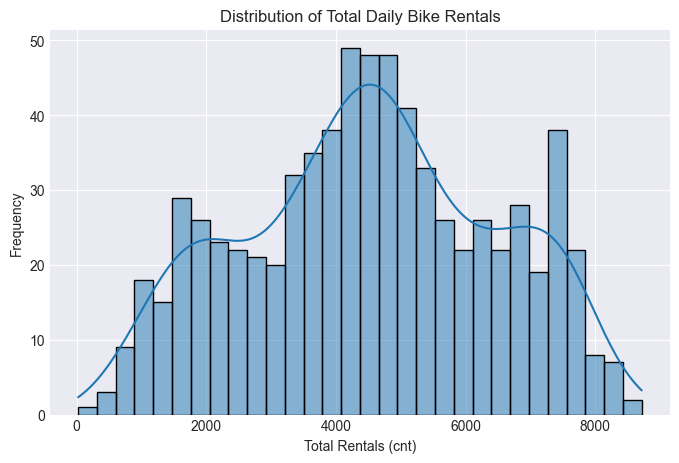

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df_day_final['cnt'], kde=True, bins=30)
plt.title('Distribution of Total Daily Bike Rentals')
plt.xlabel('Total Rentals (cnt)')
plt.ylabel('Frequency')
plt.show()

### Categorical Features vs. Total Daily Rentals (Box Plots)
Box plots are generated for each categorical feature against the cnt variable to visualize how different categories impact rental counts and to identify potential trends.


Daily Categorical Features vs. Total Rentals (Box Plots):


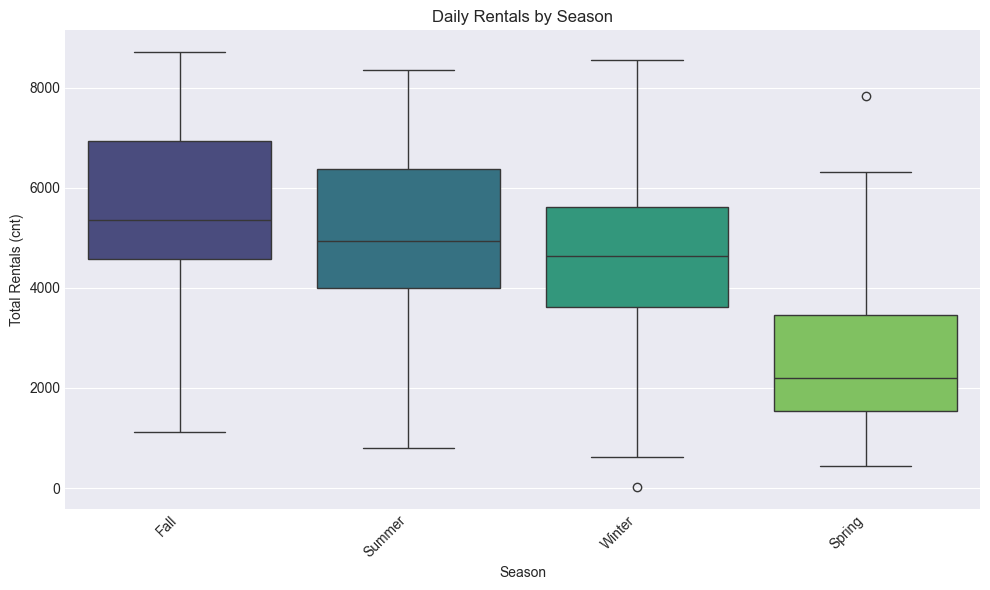

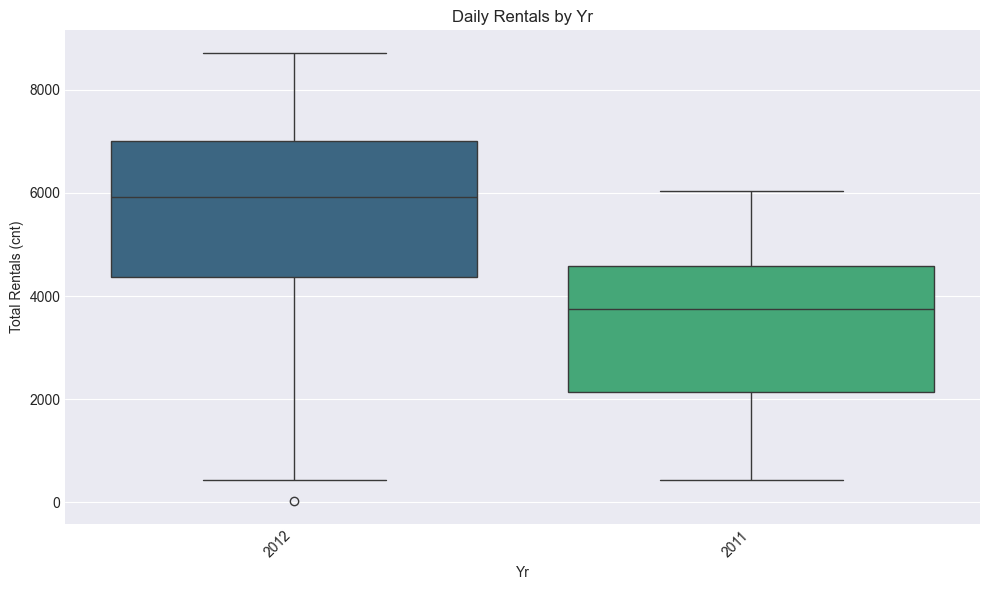

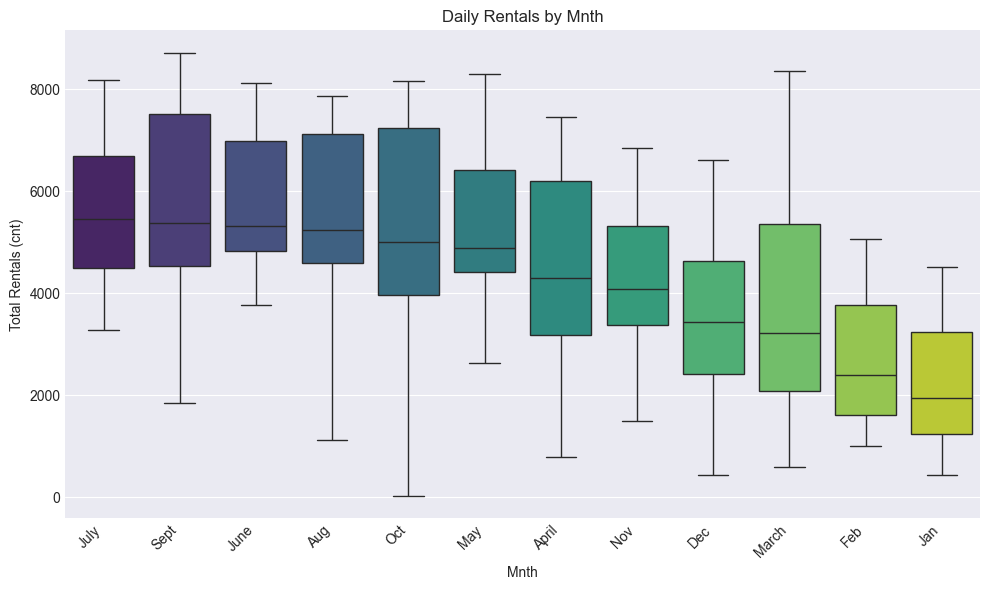

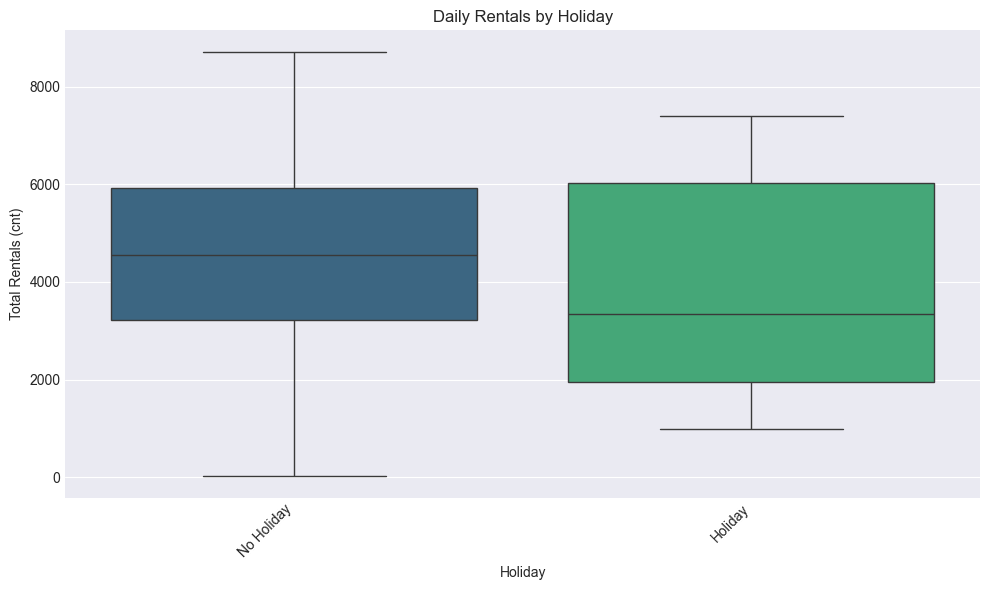

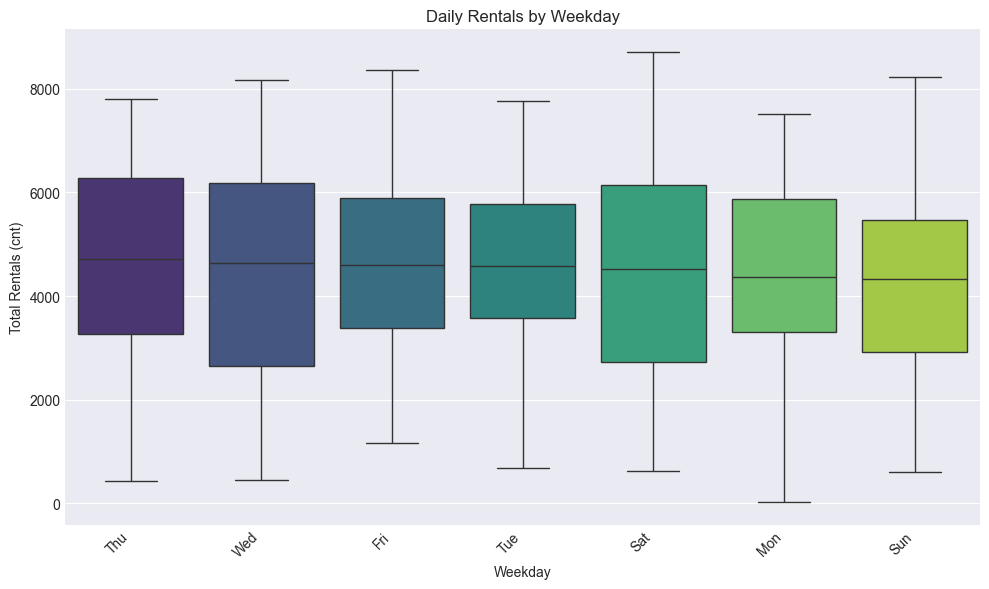

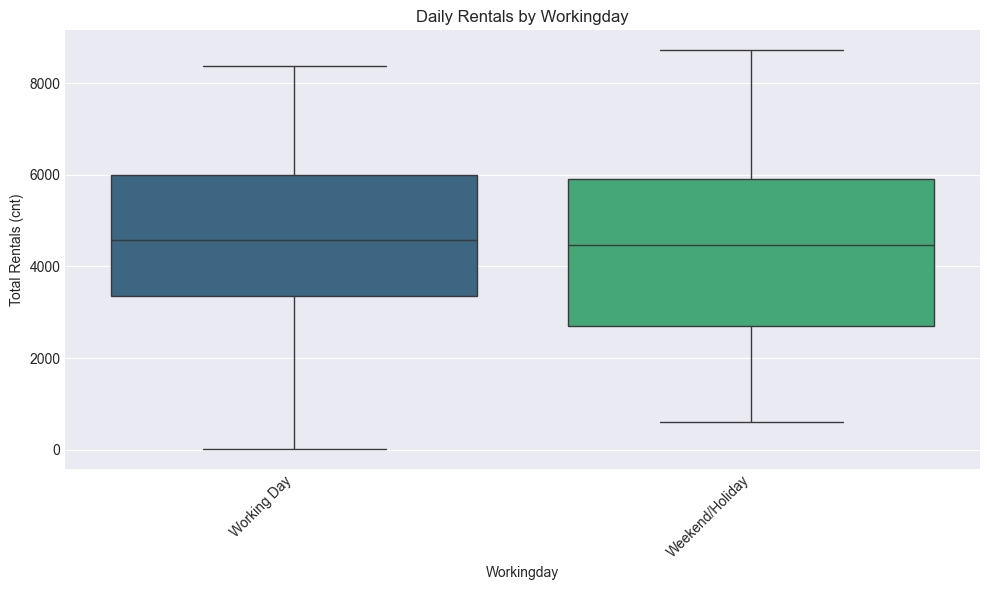

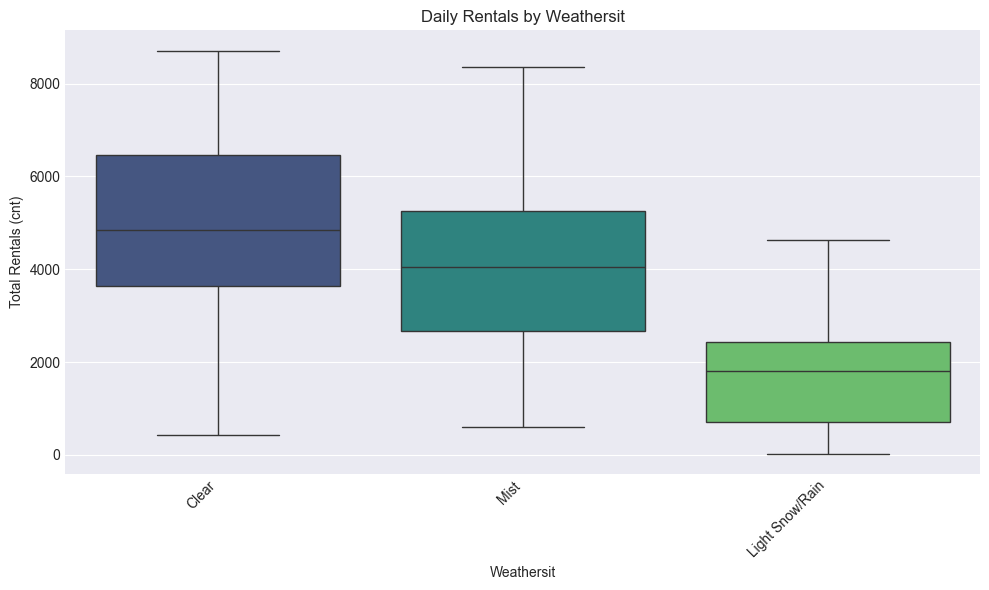

In [9]:
print("\nDaily Categorical Features vs. Total Rentals (Box Plots):")
for col in day_cat_cols_raw:
    plt.figure(figsize=(10, 6))
    temp_df_plot = day_df.copy() # Use original df for plotting labels

    temp_df_plot[col] = temp_df_plot[col].map(d_featurelabels.get(col, dict(zip(temp_df_plot[col].unique(), temp_df_plot[col].unique()))))
    order_by_median = temp_df_plot.groupby(col)['cnt'].median().sort_values(ascending=False).index

    sns.boxplot(x=col, y='cnt', data=temp_df_plot, palette='viridis', order=order_by_median)
    plt.title(f'Daily Rentals by {col.replace("_", " ").capitalize()}')
    plt.xlabel(col.replace("_", " ").capitalize())
    plt.ylabel('Total Rentals (cnt)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Correlation Heatmap for Numerical Features
A heatmap visualizes the correlation coefficients between numerical features and the target variable (cnt).


Daily Numerical Feature Correlation Heatmap:


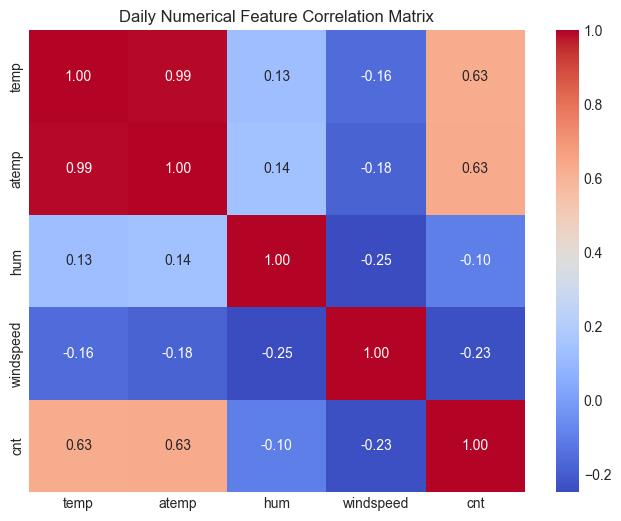

In [10]:
print("\nDaily Numerical Feature Correlation Heatmap:")
plt.figure(figsize=(8, 6))
sns.heatmap(df_day_final[numerical_cols_day + ['cnt']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Daily Numerical Feature Correlation Matrix')
plt.show()

### **Outcome**:
The cnt distribution is somewhat bell-shaped but leans towards higher values.
Box plots reveal clear differences in rental counts across seasons, months, and weather situations.
The correlation heatmap shows temp and atemp are highly correlated (as expected), and both are positively correlated with cnt.

## 6. Daily Model Training and Evaluation
### Defining Features (X) and Target (y)
The dataset is split into features (X_day) and the target variable (y_day).

In [11]:
X_day = df_day_final.drop('cnt', axis=1)
y_day = df_day_final['cnt']

### Splitting Data into Training and Testing Sets
The data is split into training (80%) and testing (20%) sets to train the model on one part and evaluate it on unseen data.

In [12]:
X_train_day, X_test_day, y_train_day, y_test_day = train_test_split(X_day, y_day, test_size=0.2, random_state=42)
print(f"Daily training data shape: {X_train_day.shape}, {y_train_day.shape}")
print(f"Daily testing data shape: {X_test_day.shape}, {y_test_day.shape}")

Daily training data shape: (584, 29), (584,)
Daily testing data shape: (147, 29), (147,)


### Training Linear Regression Model
A Scikit-learn LinearRegression model is trained on the daily training data.

In [13]:
lin_reg_day = LinearRegression()
lin_reg_day.fit(X_train_day, y_train_day)
y_pred_lr_day = lin_reg_day.predict(X_test_day)

### Daily Model Performance Metrics
Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²) are calculated to evaluate the model's accuracy.

In [14]:
mae_lr_day = mean_absolute_error(y_test_day, y_pred_lr_day)
rmse_lr_day = np.sqrt(mean_squared_error(y_test_day, y_pred_lr_day))
r2_lr_day = r2_score(y_test_day, y_pred_lr_day)

print(f"Daily Model MAE: {mae_lr_day:.2f}")
print(f"Daily Model RMSE: {rmse_lr_day:.2f}")
print(f"Daily Model R-squared: {r2_lr_day:.2f}")

Daily Model MAE: 583.02
Daily Model RMSE: 796.46
Daily Model R-squared: 0.84


### Visualization of Actual vs. Predicted Values
A scatter plot compares the actual cnt values from the test set against the model's predicted cnt values. A perfect model would have all points on the red diagonal line.

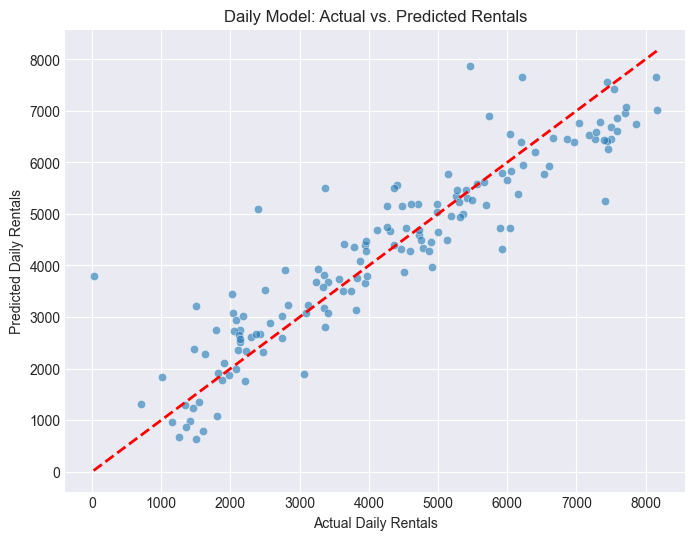

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_day, y=y_pred_lr_day, alpha=0.6)
plt.plot([y_test_day.min(), y_test_day.max()], [y_test_day.min(), y_test_day.max()], 'r--', lw=2)
plt.xlabel('Actual Daily Rentals')
plt.ylabel('Predicted Daily Rentals')
plt.title('Daily Model: Actual vs. Predicted Rentals')
plt.show()

## Daily OLS Model Summary and Residuals Analysis
The statsmodels library provides a detailed Ordinary Least Squares (OLS) summary, including coefficients, p-values, and model diagnostics. A histogram of residuals (the differences between actual and predicted values) is also plotted.


--- Daily OLS Model Summary ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     109.6
Date:                Fri, 29 Aug 2025   Prob (F-statistic):          1.10e-205
Time:                        08:54:02   Log-Likelihood:                -4694.2
No. Observations:                 584   AIC:                             9446.
Df Residuals:                     555   BIC:                             9573.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1302.29

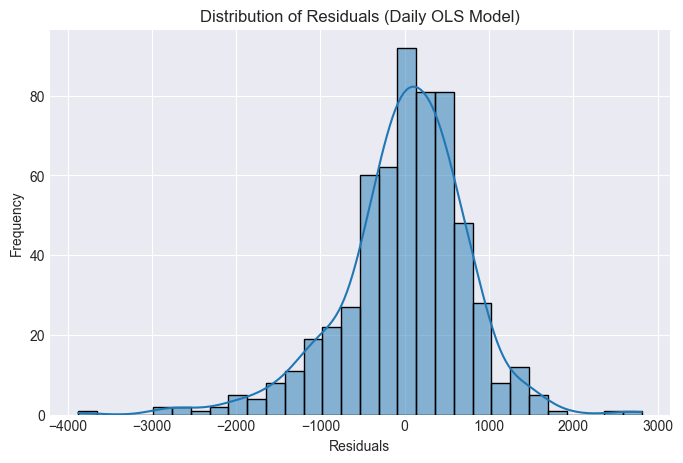

In [16]:
# Convert to NumPy arrays for statsmodels
X_train_day_np = X_train_day.to_numpy().astype(float)
y_train_day_np = y_train_day.to_numpy().astype(float)

ols_model_day = sm.OLS(y_train_day_np, sm.add_constant(X_train_day_np))
results_day = ols_model_day.fit()

print("\n--- Daily OLS Model Summary ---")
print(results_day.summary())

# Distribution of Residuals
plt.figure(figsize=(8, 5))
sns.histplot(results_day.resid, kde=True, bins=30)
plt.title('Distribution of Residuals (Daily OLS Model)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

#### **Outcome**:
The OLS summary provides detailed statistics, including p-values for each feature, indicating their statistical significance.
The residuals histogram shows how well the model's errors are distributed (ideally normally around zero).

# HOURLY DATA ANALYSIS (hour.csv)
## 7. Hourly Data Preparation
### Feature Labels for Visualization
A dictionary for hourly categorical features, including the hr (hour) column, is prepared for clearer plots.

In [17]:
hour_cat_cols_raw = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_cols_hour = ['temp', 'atemp', 'hum', 'windspeed']

# h_featurelabels is already defined as feature_labels_map globally to include 'hr'

### Data Cleaning and Feature Engineering
This section processes the hour_df: converts dteday to datetime, one-hot encodes categorical variables, and drops irrelevant columns.

In [18]:
df_hour_final = hour_df.copy()
df_hour_final['dteday'] = pd.to_datetime(df_hour_final['dteday'])

# One-hot encode categorical features, dropping the first category
df_hour_final = pd.get_dummies(df_hour_final, columns=hour_cat_cols_raw, drop_first=True)

# Drop redundant/target-component columns
df_hour_final = df_hour_final.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)

print("Processed Hourly Data (first 5 rows):")
print(df_hour_final.head())

Processed Hourly Data (first 5 rows):
   temp   atemp   hum  windspeed  cnt  season_2  season_3  season_4   yr_1  \
0  0.24  0.2879  0.81        0.0   16     False     False     False  False   
1  0.22  0.2727  0.80        0.0   40     False     False     False  False   
2  0.22  0.2727  0.80        0.0   32     False     False     False  False   
3  0.24  0.2879  0.75        0.0   13     False     False     False  False   
4  0.24  0.2879  0.75        0.0    1     False     False     False  False   

   mnth_2  ...  weekday_1  weekday_2  weekday_3  weekday_4  weekday_5  \
0   False  ...      False      False      False      False      False   
1   False  ...      False      False      False      False      False   
2   False  ...      False      False      False      False      False   
3   False  ...      False      False      False      False      False   
4   False  ...      False      False      False      False      False   

   weekday_6  workingday_1  weathersit_2  weathersit_3

## 8. Hourly EDA and Visualizations
### Distribution of Total Hourly Bike Rentals
A histogram with a KDE plot visualizes the distribution of the target variable (cnt) for hourly data.

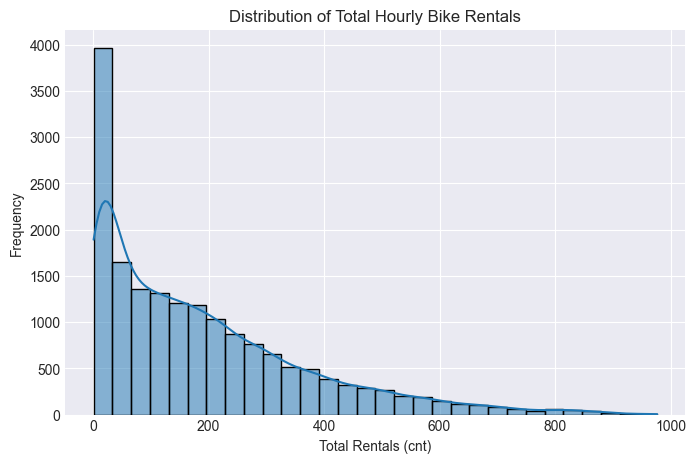

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df_hour_final['cnt'], kde=True, bins=30)
plt.title('Distribution of Total Hourly Bike Rentals')
plt.xlabel('Total Rentals (cnt)')
plt.ylabel('Frequency')
plt.show()

### Categorical Features vs. Total Hourly Rentals (Box Plots)
Box plots are generated for each categorical feature against cnt, including the crucial hr (hour) feature.

In [20]:
print("\nHourly Categorical Features vs. Total Rentals (Box Plots):")
for col in hour_cat_cols_raw:
    plt.figure(figsize=(10, 6))
    temp_df_plot = hour_df.copy() # Use original df for plotting labels

    temp_df_plot[col] = temp_df_plot[col].map(feature_labels_map.get(col, dict(zip(temp_df_plot[col].unique(), temp_df_plot[col].unique()))))
    order_by_median = temp_df_plot.groupby(col)['cnt'].median().sort_values(ascending=False).index

    sns.boxplot(x=col, y='cnt', data=temp_df_plot, palette='viridis', order=order_by_median)
    plt.title(f'Hourly Rentals by {col.replace("_", " ").capitalize()}')
    plt.xlabel(col.replace("_", " ").capitalize())
    plt.ylabel('Total Rentals (cnt)')
    if col in ['hr', 'mnth']: # Rotate labels for better readability on hourly/monthly plots
        plt.xticks(rotation=45, ha='right')
    else:
        plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


Hourly Categorical Features vs. Total Rentals (Box Plots):


NameError: name 'feature_labels_map' is not defined

<Figure size 1000x600 with 0 Axes>

### Correlation Heatmap for Numerical Features
A heatmap visualizes the Pearson correlation coefficients between numerical features and cnt for hourly data.

In [ ]:
print("\nHourly Numerical Feature Correlation Heatmap:")
plt.figure(figsize=(8, 6))
sns.heatmap(df_hour_final[numerical_cols_hour + ['cnt']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Hourly Numerical Feature Correlation Matrix')
plt.show()

### **Outcome**:
Hourly cnt distribution is also somewhat bell-shaped, but likely more peaked with higher frequencies for certain hours.
Box plots clearly show strong hourly patterns in rental demand.
Correlation of temp and atemp with cnt remains high.

## 9. Hourly Model Training and Evaluation
### defining Features (X) and Target (y)
The hourly dataset is split into features (X_hour) and the target variable (y_hour).

In [ ]:
X_hour = df_hour_final.drop('cnt', axis=1)
y_hour = df_hour_final['cnt']

### Splitting Data into Training and Testing Sets
The hourly data is split into training (80%) and testing (20%) sets.

In [ ]:
X_train_hour, X_test_hour, y_train_hour, y_test_hour = train_test_split(X_hour, y_hour, test_size=0.2, random_state=42)
print(f"Hourly training data shape: {X_train_hour.shape}, {y_train_hour.shape}")
print(f"Hourly testing data shape: {X_test_hour.shape}, {y_test_hour.shape}")

### Training Linear Regression Model
A Scikit-learn LinearRegression model is trained on the hourly training data.

In [ ]:
lin_reg_hour = LinearRegression()
lin_reg_hour.fit(X_train_hour, y_train_hour)
y_pred_lr_hour = lin_reg_hour.predict(X_test_hour)

### Hourly Model Performance Metrics
MAE, RMSE, and R-squared are calculated to evaluate the hourly model's accuracy.

In [ ]:
mae_lr_hour = mean_absolute_error(y_test_hour, y_pred_lr_hour)
rmse_lr_hour = np.sqrt(mean_squared_error(y_test_hour, y_pred_lr_hour))
r2_lr_hour = r2_score(y_test_hour, y_pred_lr_hour)

print(f"Hourly Model MAE: {mae_lr_hour:.2f}")
print(f"Hourly Model RMSE: {rmse_lr_hour:.2f}")
print(f"Hourly Model R-squared: {r2_lr_hour:.2f}")

### Visualization of Actual vs. Predicted Values
A scatter plot compares the actual cnt values against the model's predicted cnt values for hourly data.

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_hour, y=y_pred_lr_hour, alpha=0.6)
plt.plot([y_test_hour.min(), y_test_hour.max()], [y_test_hour.min(), y_test_hour.max()], 'r--', lw=2)
plt.xlabel('Actual Hourly Rentals')
plt.ylabel('Predicted Hourly Rentals')
plt.title('Hourly Model: Actual vs. Predicted')
plt.show()

### Hourly OLS Model Summary and Residuals Analysis
The OLS summary and a histogram of residuals are generated for the hourly model.

In [ ]:
# Convert to NumPy arrays for statsmodels
X_train_hour_np = X_train_hour.to_numpy().astype(float)
y_train_hour_np = y_train_hour.to_numpy().astype(float)

ols_model_hour = sm.OLS(y_train_hour_np, sm.add_constant(X_train_hour_np))
results_hour = ols_model_hour.fit()

print("\n--- Hourly OLS Model Summary ---")
print(results_hour.summary())

# Distribution of Residuals
plt.figure(figsize=(8, 5))
sns.histplot(results_hour.resid, kde=True, bins=30)
plt.title('Distribution of Residuals (Hourly OLS Model)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

### **Outcome**:
The hourly model typically shows a higher R-squared due to more granular data and the strong influence of the hr feature.
Residuals analysis helps confirm model fit.

## 10. Conclusion and Future Work
### Summary of Work Performed
This project successfully loaded, cleaned, and explored both daily and hourly bike sharing datasets. Separate Linear Regression models were built and evaluated for each, providing predictions based on environmental and seasonal factors. Essential visualizations helped in understanding data distributions and model performance.
### Key Findings and Insights
Data Completeness: Both datasets were complete with no missing values.
Strong Seasonal/Hourly Trends: Bike rentals are heavily influenced by season, month, day of week, and especially the hour of the day.  
Weather Impact: Temperature (temp, atemp) showed strong positive correlation with rentals, while weathersit also played a significant role.  
Model Performance: Linear Regression models provided reasonable predictions for both daily and hourly data, with the hourly model likely capturing more variance due to the hr feature. The OLS summaries highlighted statistically significant features.  
Conclusion and Future Work
This project demonstrated a foundational approach to predicting bike rental demand using linear regression. The models provide a solid baseline for understanding key drivers.  